# Classifying Nanoparticle Ordering in SEM Images with ML


## 1. Environment and configuration
Install any missing packages and set the seed, class order, and working directories.


In [1]:
import importlib.util, subprocess, sys

# Import each module and pip-install only the ones that are missing.
def ensure(packages):
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

ensure([("numpy", "numpy"), ("pandas", "pandas"), ("PIL", "pillow"),
        ("skimage", "scikit-image"), ("sklearn", "scikit-learn"), ("matplotlib", "matplotlib")])
print("Core dependencies ready.")


Core dependencies ready.


In [2]:
import csv, time, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from skimage.feature import canny, hog
from skimage.measure import shannon_entropy, label as cc_label, regionprops
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, recall_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

SEED = 446
np.random.seed(SEED)
RUN_CNN = True

# Fix the label order so every metric reports the same positive class.
CLASS_LABELS = ["disordered", "ordered"]

# Optional deep-learning backend for the Section 10 upper bound; the notebook still runs without it.
if RUN_CNN:
    ensure([("torch", "torch"), ("torchvision", "torchvision")])
try:
    import torch
    from torchvision import models, transforms
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

# Create working directories for raw data, cropped images, feature caches, and figures.
WORKDIR = Path("mse446_workdir").resolve()
RAW_DIR, IMAGE_DIR, CACHE_DIR, FIG_DIR = (WORKDIR / p for p in ("raw", "images", "cache", "figures"))
for d in (RAW_DIR, IMAGE_DIR, CACHE_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "font.size": 10})
print("Setup complete.")

Setup complete.


## 2. Data acquisition
Download the two figshare articles (750 ordered, 250 disordered crops) and extract them locally.


In [3]:
# Map each figshare article id to its class label.
ARTICLES = {"11783661": "ordered", "11783667": "disordered"}
FIGSHARE_ZIP = "https://ndownloader.figshare.com/articles/{article_id}/versions/1"

# Stream a URL to disk with a light progress readout.
def download_file(url, dest, chunk=1 << 20):
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=120) as response:
        total, done, last = int(response.headers.get("Content-Length", 0)), 0, time.time()
        with open(dest, "wb") as handle:
            for block in iter(lambda: response.read(chunk), b""):
                handle.write(block)
                done += len(block)
                if time.time() - last > 3:
                    print(f"  {dest.name}: {100 * done / total:5.1f}%" if total
                          else f"  {dest.name}: {done >> 20} MB", end="\r")
                    last = time.time()
    print(f"  {dest.name}: downloaded {dest.stat().st_size >> 20} MB")

# Download and extract one figshare article, skipping work already done.
def fetch_article(article_id):
    label = ARTICLES[article_id]
    out_dir = RAW_DIR / label
    out_dir.mkdir(parents=True, exist_ok=True)
    if list(out_dir.rglob("*.tif")):
        print(f"{label}: already extracted ({len(list(out_dir.rglob('*.tif')))} tif files)")
        return
    zip_path = RAW_DIR / f"{article_id}.zip"
    if not zip_path.exists():
        print(f"{label}: downloading article {article_id} ...")
        download_file(FIGSHARE_ZIP.format(article_id=article_id), zip_path)
    print(f"{label}: extracting ...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    zip_path.unlink(missing_ok=True)
    print(f"{label}: {len(list(out_dir.rglob('*.tif')))} tif files ready")

for article_id in ARTICLES:
    fetch_article(article_id)


ordered: already extracted (750 tif files)
disordered: already extracted (250 tif files)


### 2.1 Build the working dataset
Apply the published banner crop to every image and parse acquisition metadata used only for
auditing and splitting, never as a model input.


In [4]:
# The published processing notebook crops each micrograph at row 890 to drop the instrument banner.
CROP_BOTTOM_ROW = 890
MAG_NAMES = {50000: "50k", 100000: "100k", 200000: "200k"}

# Format a value such as 10.0 into a filename-safe token like '10p0kV'.
def token(value, suffix):
    return f"{value:.1f}".replace(".", "p") + suffix

# Map every original filename to its acquisition-metadata row.
def load_descriptions(article_dir):
    table = {}
    for csv_path in article_dir.rglob("*description_w_units.csv"):
        with open(csv_path, newline="", encoding="utf-8-sig") as handle:
            for row in csv.DictReader(handle):
                clean = {key.split(",")[0].strip(): val for key, val in row.items()}
                table[clean["Filename"].strip()] = clean
    if not table:
        raise FileNotFoundError(f"No *_description_w_units.csv under {article_dir}")
    return table

# Build a metadata-encoding filename that gives a stable, auditable row order.
def canonical_name(original_name, meta, label):
    stem = Path(original_name).stem
    image_id = int(stem.split("-")[0])
    kv = token(float(meta["AcceleratingVoltage"]) / 1000.0, "kV")
    mm = token(float(meta["WorkingDistance"]) / 1000.0, "mm")
    mag = MAG_NAMES[int(float(meta["Magnification"]))]
    return (f"kv-{kv}__mm-{mm}__label-{label}__sample-{meta['Sample'].strip()}"
            f"__area-{meta['Area'].strip()}__mag-{mag}__id-{image_id}__orig-{stem}.tif")

# Apply the published banner crop and save the image.
def crop_banner(source_path, dest_path):
    with Image.open(source_path) as image:
        array = np.asarray(image)
    if array.shape[0] <= CROP_BOTTOM_ROW:
        raise ValueError(f"{source_path.name}: height {array.shape[0]} <= {CROP_BOTTOM_ROW}")
    Image.fromarray(array[:CROP_BOTTOM_ROW]).save(dest_path)

# Crop every raw image and return the assembled metadata table.
def build_metadata():
    records = []
    for label in ARTICLES.values():
        article_dir = RAW_DIR / label
        descriptions = load_descriptions(article_dir)
        for source in article_dir.rglob("*.tif"):
            meta = descriptions.get(source.name)
            if meta is None:
                continue
            name = canonical_name(source.name, meta, label)
            dest = IMAGE_DIR / name
            if not dest.exists():
                crop_banner(source, dest)
            records.append({
                "filename": name, "path": str(dest), "label": label,
                "sample": meta["Sample"].strip(), "area": meta["Area"].strip(),
                "kv": token(float(meta["AcceleratingVoltage"]) / 1000.0, "kV"),
                "mm": token(float(meta["WorkingDistance"]) / 1000.0, "mm"),
                "mag": MAG_NAMES[int(float(meta["Magnification"]))]})
    frame = pd.DataFrame(records)
    # Group crops by specimen area so repeated crops never straddle a split.
    frame["area_group"] = frame["sample"] + "__" + frame["area"]
    return frame.sort_values("filename").reset_index(drop=True)

metadata = build_metadata()
print(f"Prepared {len(metadata)} images.")
metadata.drop(columns="path").head(3)


Prepared 1000 images.


,filename,label,sample,area,kv,mm,mag,area_group
0,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,10p0kV,11p3mm,100k,S1__no_area
1,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,10p0kV,11p3mm,100k,S1__no_area
2,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,10p0kV,11p3mm,100k,S1__no_area


## 3. Dataset audit
Summarize the 3:1 class imbalance and the uneven voltage distribution that together drive the grouped splitting and the later voltage holdout test.

In [5]:
print(f"Total images: {len(metadata)}")
print("\nLabel counts:\n" + metadata["label"].value_counts().to_string())
print("\nCounts by magnification and label:\n" + metadata.groupby(["mag", "label"]).size().to_string())
print("\nCounts by voltage and label:\n" + metadata.groupby(["kv", "label"]).size().to_string())
print(f"\nUnique specimen-area groups: {metadata['area_group'].nunique()}")


Total images: 1000

Label counts:
label
ordered       750
disordered    250

Counts by magnification and label:
mag   label     
100k  disordered     99
      ordered       351
200k  disordered     59
      ordered       162
50k   disordered     92
      ordered       237

Counts by voltage and label:
kv      label     
10p0kV  disordered     44
        ordered       167
20p0kV  disordered     21
        ordered       153
30p0kV  disordered    185
        ordered       430

Unique specimen-area groups: 292


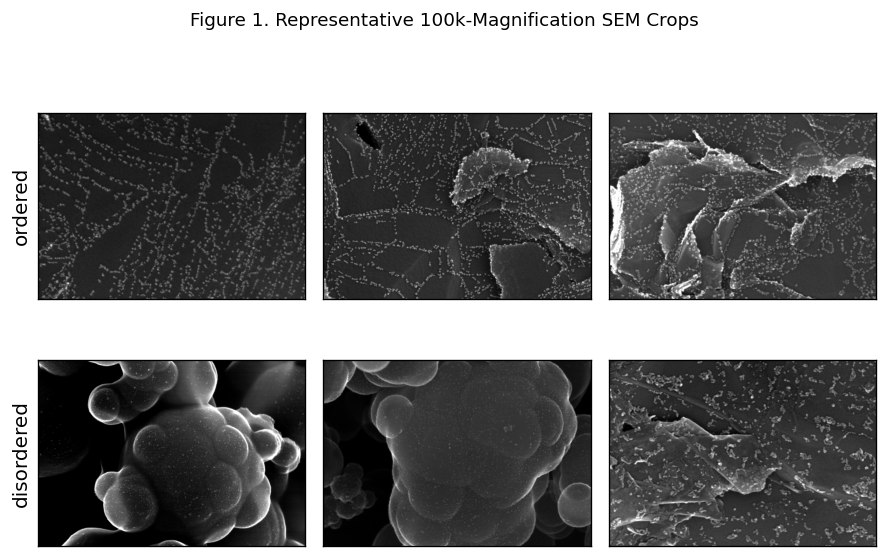

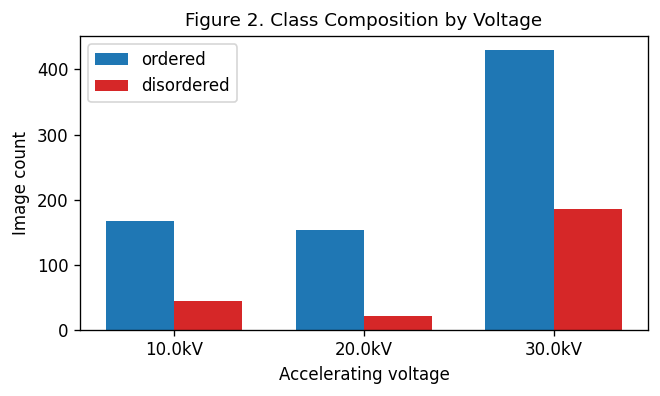

In [6]:
# Figure 1 shows representative ordered and disordered crops at one magnification.
fig, axes = plt.subplots(2, 3, figsize=(7.5, 5.2))
for r, label in enumerate(["ordered", "disordered"]):
    picks = metadata[(metadata["label"] == label) & (metadata["mag"] == "100k")].sample(3, random_state=11)
    for c, (_, row) in enumerate(picks.iterrows()):
        with Image.open(row["path"]) as im:
            axes[r, c].imshow(np.asarray(im.convert("L")), cmap="gray")
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if c == 0:
            axes[r, c].set_ylabel(label, fontsize=12)
fig.suptitle("Figure 1. Representative 100k-Magnification SEM Crops", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig1_examples.png"); plt.show()

# Figure 2 shows that labels are unevenly distributed across voltage, the confound tested later.
comp = metadata.groupby(["kv", "label"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(5.6, 3.4))
x = np.arange(len(comp.index))
ax.bar(x - 0.18, comp["ordered"], 0.36, label="ordered", color="#1f77b4")
ax.bar(x + 0.18, comp["disordered"], 0.36, label="disordered", color="#d62728")
ax.set_xticks(x); ax.set_xticklabels([s.replace("p", ".") for s in comp.index])
ax.set_xlabel("Accelerating voltage"); ax.set_ylabel("Image count")
ax.set_title("Figure 2. Class Composition by Voltage", fontsize=11); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig2_composition.png"); plt.show()


## 4. Feature extraction
Extract three engineered feature families (basic global statistics, HOG texture, and connected component morphology), caching each table to disk.

In [7]:
TRACKING = ["filename", "label", "sample", "area", "area_group", "kv", "mm", "mag"]
BASIC_COLS = ["mean_intensity", "std_intensity", "min_intensity", "max_intensity",
              "p10_intensity", "p25_intensity", "p50_intensity", "p75_intensity",
              "p90_intensity", "entropy", "bright_pixel_ratio", "edge_density"]
COMPONENT_COLS = ["component_count", "component_density", "component_bright_pixel_ratio",
                  "mean_component_area", "median_component_area", "std_component_area",
                  "max_component_area", "min_component_area", "total_component_area",
                  "largest_component_area_ratio", "mean_eccentricity", "std_eccentricity",
                  "mean_solidity", "std_solidity", "mean_perimeter", "std_perimeter",
                  "mean_major_axis_length", "mean_minor_axis_length"]
HOG_KW = dict(orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2),
              block_norm="L2-Hys", transform_sqrt=True, feature_vector=True)

# Load an image as normalized grayscale, resized to a fixed shape.
def load_gray(path, size):
    with Image.open(path) as image:
        gray = image.convert("L").resize(size, Image.Resampling.BILINEAR)
    return np.asarray(gray, dtype=np.float32) / 255.0

# Compute intensity statistics, entropy, bright-pixel ratio, and edge density.
def basic_features(image):
    p10, p25, p50, p75, p90 = np.percentile(image, [10, 25, 50, 75, 90])
    return {"mean_intensity": float(image.mean()), "std_intensity": float(image.std()),
            "min_intensity": float(image.min()), "max_intensity": float(image.max()),
            "p10_intensity": float(p10), "p25_intensity": float(p25), "p50_intensity": float(p50),
            "p75_intensity": float(p75), "p90_intensity": float(p90),
            "entropy": float(shannon_entropy(image)),
            "bright_pixel_ratio": float(np.mean(image > p90)),
            "edge_density": float(np.mean(canny(image, sigma=1.0)))}

# Threshold bright particle-like blobs and summarize their count, area, and shape.
def component_features(image):
    area = image.shape[0] * image.shape[1]
    try:
        thr = threshold_otsu(image)
    except ValueError:
        thr = float(np.percentile(image, 85))
    if not np.isfinite(thr) or thr <= float(image.min()):
        thr = float(np.percentile(image, 85))
    mask = remove_small_objects(image > thr, max_size=7)
    bright_ratio = float(mask.mean())
    props = regionprops(cc_label(mask, connectivity=2))
    if not props:
        return {c: 0.0 for c in COMPONENT_COLS} | {"component_bright_pixel_ratio": bright_ratio}
    areas = np.array([p.area for p in props], float)
    max_area = float(areas.max())
    return {"component_count": float(len(props)), "component_density": len(props) / area,
            "component_bright_pixel_ratio": bright_ratio,
            "mean_component_area": float(areas.mean()), "median_component_area": float(np.median(areas)),
            "std_component_area": float(areas.std()), "max_component_area": max_area,
            "min_component_area": float(areas.min()), "total_component_area": float(areas.sum()),
            "largest_component_area_ratio": max_area / area,
            "mean_eccentricity": float(np.mean([p.eccentricity for p in props])),
            "std_eccentricity": float(np.std([p.eccentricity for p in props])),
            "mean_solidity": float(np.mean([p.solidity for p in props])),
            "std_solidity": float(np.std([p.solidity for p in props])),
            "mean_perimeter": float(np.mean([p.perimeter for p in props])),
            "std_perimeter": float(np.std([p.perimeter for p in props])),
            "mean_major_axis_length": float(np.mean([p.axis_major_length for p in props])),
            "mean_minor_axis_length": float(np.mean([p.axis_minor_length for p in props]))}

# Extract one feature family for every image, in metadata row order.
def extract_table(meta, kind):
    rows = []
    for n, (_, row) in enumerate(meta.iterrows(), 1):
        if kind == "basic":
            feats = basic_features(load_gray(row["path"], (256, 256)))
        elif kind == "components":
            feats = component_features(load_gray(row["path"], (256, 256)))
        else:
            feats = {f"hog_{i:04d}": float(v) for i, v in enumerate(hog(load_gray(row["path"], (128, 128)), **HOG_KW))}
        rows.append({col: row[col] for col in TRACKING} | feats)
        if n % 250 == 0:
            print(f"  {kind}: {n}/{len(meta)}")
    return pd.DataFrame(rows)

# Return a cached feature table, building and saving it on first use.
def load_or_build(kind):
    cache = CACHE_DIR / f"features_{kind}.csv"
    if cache.exists():
        return pd.read_csv(cache)
    print(f"Extracting {kind} features ...")
    table = extract_table(metadata, kind)
    table.to_csv(cache, index=False)
    return table

feat_basic, feat_hog, feat_comp = load_or_build("basic"), load_or_build("hog"), load_or_build("components")
print("basic:", feat_basic.shape, "| hog:", feat_hog.shape, "| components:", feat_comp.shape)


Extracting basic features ...


  basic: 250/1000


  basic: 500/1000


  basic: 750/1000


  basic: 1000/1000
Extracting hog features ...


...

Extracting components features ...


  components: 250/1000


  components: 500/1000


  components: 750/1000


  components: 1000/1000
basic: (1000, 20) | hog: (1000, 1772) | components: (1000, 26)


### 4.1 Assemble the feature families
Stack the cached tables into the three feature matrices the ablation compares.


In [8]:
# Labels, groups, and voltage are shared across families because rows are aligned.
HOG_COLS = [c for c in feat_hog.columns if c.startswith("hog_")]
y, groups, kv = feat_basic["label"], feat_basic["area_group"], feat_basic["kv"]

FAMILIES = {
    "basic": feat_basic[BASIC_COLS],
    "basic+hog": pd.concat([feat_basic[BASIC_COLS], feat_hog[HOG_COLS]], axis=1),
    "basic+morphology": pd.concat([feat_basic[BASIC_COLS], feat_comp[COMPONENT_COLS]], axis=1)}
for name, X in FAMILIES.items():
    print(f"{name:>18s}: {X.shape[1]} features")


             basic: 12 features
         basic+hog: 1776 features
  basic+morphology: 30 features


## 5. Evaluation protocol
Define the grouped splitting, the balanced class weighting, and the balanced accuracy and macro F1 metrics used throughout.

In [9]:
# Return the label proportions in a fixed class order.
def _proportions(labels):
    return labels.value_counts(normalize=True).reindex(CLASS_LABELS, fill_value=0.0)

# Pick the group-disjoint 80/20 split whose test balance best matches the full set.
def choose_benchmark_split(meta, test_size=0.20, n_seeds=1000):
    labels, grp, placeholder = meta["label"], meta["area_group"], np.zeros((len(meta), 1))
    best = None
    for seed in range(n_seeds):
        tr, te = next(GroupShuffleSplit(1, test_size=test_size, random_state=seed).split(placeholder, labels, grp))
        if labels.iloc[tr].nunique() < 2 or labels.iloc[te].nunique() < 2:
            continue
        if not set(grp.iloc[tr]).isdisjoint(set(grp.iloc[te])):
            continue
        distance = float(np.abs(_proportions(labels) - _proportions(labels.iloc[te])).sum())
        if best is None or distance < best[2]:
            best = (tr, te, distance, seed)
    if best is None:
        raise RuntimeError("No valid group-aware split found.")
    return best[0], best[1], best[3]

# Yield the first n group-disjoint splits that keep both classes on each side.
def valid_group_splits(labels, grp, n_splits=20, test_size=0.20):
    splits, placeholder, seed = [], np.zeros((len(labels), 1)), 0
    while len(splits) < n_splits and seed < n_splits * 10:
        tr, te = next(GroupShuffleSplit(1, test_size=test_size, random_state=seed).split(placeholder, labels, grp))
        both = labels.iloc[tr].nunique() == 2 and labels.iloc[te].nunique() == 2
        if both and set(grp.iloc[tr]).isdisjoint(set(grp.iloc[te])):
            splits.append((tr, te))
        seed += 1
    return splits

# Compute the headline metrics for one set of predictions.
def score(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "disordered_recall": recall_score(y_true, y_pred, labels=CLASS_LABELS, average=None, zero_division=0)[0]}

train_idx, test_idx, bench_seed = choose_benchmark_split(metadata)
assert set(groups.iloc[train_idx]).isdisjoint(set(groups.iloc[test_idx])), "split leakage!"
print(f"Benchmark split: seed {bench_seed}, train {len(train_idx)}, test {len(test_idx)}")
print("Test label counts:", y.iloc[test_idx].value_counts().to_dict())


Benchmark split: seed 140, train 852, test 148
Test label counts: {'ordered': 111, 'disordered': 37}


In [10]:
# Build the majority baseline plus the three proposal models: linear, ensemble, kernel.
def make_models():
    return {"dummy (majority)": DummyClassifier(strategy="most_frequent"),
            "logistic_regression": make_pipeline(StandardScaler(),
                LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
            "random_forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                random_state=SEED, n_jobs=-1),
            "svc_rbf": make_pipeline(StandardScaler(),
                SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=SEED))}
print("Models:", list(make_models()))


Models: ['dummy (majority)', 'logistic_regression', 'random_forest', 'svc_rbf']


## 6. Model comparison
Screen every classical family on basic features, then study the three the proposal keeps (logistic regression, random forest, and RBF SVM) against the majority baseline.

In [11]:
# Rank all families on basic features over 20 group-aware splits.
def pilot_screening():
    candidates = {
        "dummy": DummyClassifier(strategy="most_frequent"),
        "logistic_regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
        "decision_tree": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
        "gaussian_nb": make_pipeline(StandardScaler(), GaussianNB()),
        "knn": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "random_forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1),
        "svc_rbf": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=SEED))}
    X, split_list, rows = FAMILIES["basic"], valid_group_splits(y, groups), []
    for name, proto in candidates.items():
        f1s = np.array([f1_score(y.iloc[te], clone(proto).fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te]),
                                 average="macro", zero_division=0) for tr, te in split_list])
        rows.append({"model": name, "macro_f1_mean": f1s.mean(), "macro_f1_std": f1s.std(ddof=1)})
    return pd.DataFrame(rows).sort_values("macro_f1_mean", ascending=False).round(3)

pilot = pilot_screening()
print("Pilot screening on basic features (macro F1 over 20 splits):\n")
print(pilot.to_string(index=False))
print("\nRandom forest and the RBF SVM are the strongest. We carry them forward with logistic regression as the interpretable linear baseline, and set the other families aside.")


Pilot screening on basic features (macro F1 over 20 splits):

              model  macro_f1_mean  macro_f1_std
      random_forest          0.811         0.061
            svc_rbf          0.801         0.065
                knn          0.759         0.043
      decision_tree          0.755         0.061
logistic_regression          0.743         0.095
        gaussian_nb          0.713         0.048
              dummy          0.408         0.043

Random forest and the RBF SVM are the strongest. We carry them forward with logistic regression as the interpretable linear baseline, and set the other families aside.


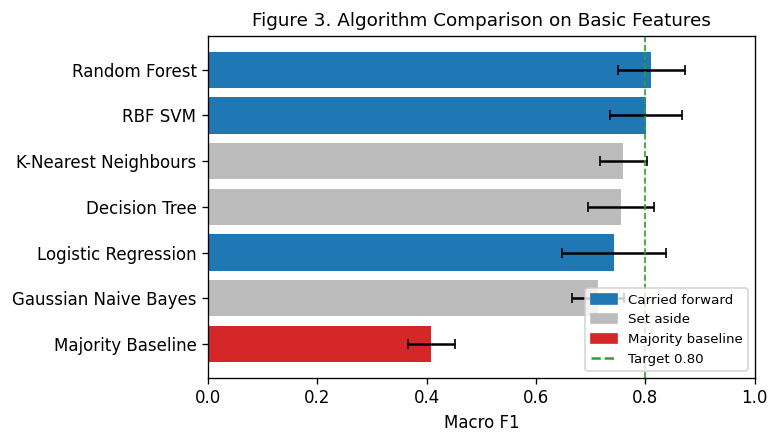

In [12]:
# Figure 3 visualizes the pilot screening, ranking every candidate family by macro F1.
display_name = {"random_forest": "Random Forest", "svc_rbf": "RBF SVM",
                "knn": "K-Nearest Neighbours", "decision_tree": "Decision Tree",
                "logistic_regression": "Logistic Regression", "gaussian_nb": "Gaussian Naive Bayes",
                "dummy": "Majority Baseline"}
carried = {"logistic_regression", "random_forest", "svc_rbf"}
ranked = pilot.sort_values("macro_f1_mean")
bar_colors = ["#d62728" if m == "dummy" else "#1f77b4" if m in carried else "#bcbcbc"
              for m in ranked["model"]]
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh([display_name[m] for m in ranked["model"]], ranked["macro_f1_mean"],
        xerr=ranked["macro_f1_std"], color=bar_colors, capsize=3)
ax.axvline(0.80, color="#2ca02c", ls="--", lw=1)
ax.set_xlim(0, 1.0); ax.set_xlabel("Macro F1")
ax.set_title("Figure 3. Algorithm Comparison on Basic Features", fontsize=11)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color="#1f77b4"),
                  plt.Rectangle((0, 0), 1, 1, color="#bcbcbc"),
                  plt.Rectangle((0, 0), 1, 1, color="#d62728"),
                  plt.Line2D([0], [0], color="#2ca02c", ls="--")]
ax.legend(legend_handles, ["Carried forward", "Set aside", "Majority baseline", "Target 0.80"],
          fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig3_screening.png"); plt.show()

In [13]:
# Evaluate the baseline and the three selected models on the benchmark split.
def benchmark_table(X):
    Xtr, Xte, ytr, yte = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
    rows = []
    for name, model in make_models().items():
        model.fit(Xtr, ytr)
        rows.append({"model": name, **{k: round(v, 3) for k, v in score(yte, model.predict(Xte)).items()}})
    return pd.DataFrame(rows)

print("Benchmark split, basic + morphology features:\n")
print(benchmark_table(FAMILIES["basic+morphology"]).to_string(index=False))


Benchmark split, basic + morphology features:



              model  accuracy  balanced_accuracy  macro_f1  disordered_recall
   dummy (majority)     0.750              0.500     0.429              0.000
logistic_regression     0.865              0.856     0.831              0.838
      random_forest     0.946              0.919     0.927              0.865
            svc_rbf     0.926              0.914     0.903              0.892


              precision    recall  f1-score   support

  disordered       0.82      0.89      0.86        37
     ordered       0.96      0.94      0.95       111

    accuracy                           0.93       148
   macro avg       0.89      0.91      0.90       148
weighted avg       0.93      0.93      0.93       148



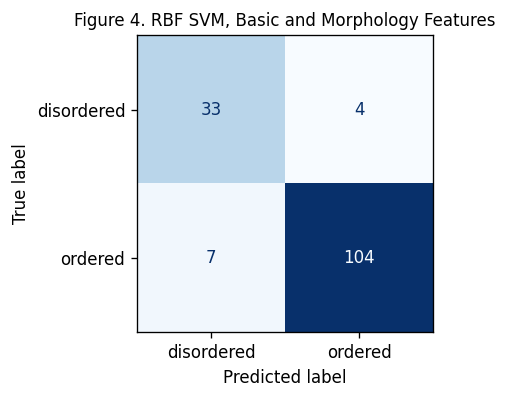

In [14]:
# Figure 4 is the confusion matrix of the strongest engineered model on the benchmark split.
Xtr, Xte = FAMILIES["basic+morphology"].iloc[train_idx], FAMILIES["basic+morphology"].iloc[test_idx]
pred = make_models()["svc_rbf"].fit(Xtr, y.iloc[train_idx]).predict(Xte)
print(classification_report(y.iloc[test_idx], pred, labels=CLASS_LABELS, zero_division=0))

fig, ax = plt.subplots(figsize=(3.8, 3.8))
ConfusionMatrixDisplay.from_predictions(y.iloc[test_idx], pred, labels=CLASS_LABELS,
                                        cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Figure 4. RBF SVM, Basic and Morphology Features", fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig4_confusion.png"); plt.show()


### 6.1 Hyperparameter tuning with grouped cross validation
Tune the random forest and SVM with a grouped grid search so tuning never sees a test group.

In [15]:
# Tune one estimator with GroupKFold on the training split and report its benchmark-split macro F1.
def tune(estimator, param_grid, X):
    gtr = groups.iloc[train_idx]
    search = GridSearchCV(estimator, param_grid, scoring="f1_macro",
                          cv=GroupKFold(n_splits=min(5, gtr.nunique())), n_jobs=-1)
    search.fit(X.iloc[train_idx], y.iloc[train_idx], groups=gtr)
    test_macro = f1_score(y.iloc[test_idx], search.predict(X.iloc[test_idx]), average="macro", zero_division=0)
    return search, test_macro

X_morph = FAMILIES["basic+morphology"]
rf_search, rf_test = tune(RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
                          {"n_estimators": [200], "max_depth": [8, 12, None],
                           "min_samples_leaf": [1, 2, 5], "max_features": ["sqrt", "log2"]}, X_morph)
print("Random forest, best parameters:", rf_search.best_params_)
print(f"  CV macro F1 {rf_search.best_score_:.3f} | benchmark-split macro F1 {rf_test:.3f}")

svc_search, svc_test = tune(make_pipeline(StandardScaler(), SVC(class_weight="balanced", random_state=SEED)),
                            {"svc__C": [0.1, 1, 10, 100], "svc__kernel": ["linear", "rbf"],
                             "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1]}, X_morph)
print("RBF SVM, best parameters:", svc_search.best_params_)
print(f"  CV macro F1 {svc_search.best_score_:.3f} | benchmark-split macro F1 {svc_test:.3f}")


Random forest, best parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
  CV macro F1 0.789 | benchmark-split macro F1 0.936


RBF SVM, best parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
  CV macro F1 0.808 | benchmark-split macro F1 0.903


## 7. Robustness and feature ablation over 20 splits
Report the mean and standard deviation of macro F1 for every model and feature family to test the 0.80 hypothesis with error bars and check whether morphology beats generic features.

In [16]:
MODEL_PROTOS = {k: v for k, v in make_models().items() if k != "dummy (majority)"}

# Evaluate every model on every feature family across the 20 group-aware splits.
def robustness_over_families():
    split_list, records = valid_group_splits(y, groups), []
    for fam, X in FAMILIES.items():
        for name, proto in MODEL_PROTOS.items():
            f1s = np.array([f1_score(y.iloc[te], clone(proto).fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te]),
                                     average="macro", zero_division=0) for tr, te in split_list])
            records.append({"family": fam, "model": name, "macro_f1_mean": f1s.mean(),
                            "macro_f1_std": f1s.std(ddof=1), "macro_f1_min": f1s.min(), "macro_f1_max": f1s.max()})
    return pd.DataFrame(records), len(split_list)

ablation, n_splits = robustness_over_families()
print(f"Macro F1 over {n_splits} group-aware splits (mean ± std):\n")
print(ablation.round(3).to_string(index=False))

# The majority-baseline floor is the mean dummy macro F1 across the same splits.
dummy_f1 = np.mean([f1_score(y.iloc[te], DummyClassifier(strategy="most_frequent").fit(
    FAMILIES["basic"].iloc[tr], y.iloc[tr]).predict(FAMILIES["basic"].iloc[te]), average="macro", zero_division=0)
    for tr, te in valid_group_splits(y, groups)])
print(f"\nMajority-baseline macro F1 (mean over splits): {dummy_f1:.3f}")


Macro F1 over 20 group-aware splits (mean ± std):

          family               model  macro_f1_mean  macro_f1_std  macro_f1_min  macro_f1_max
           basic logistic_regression          0.743         0.095         0.575         0.857
           basic       random_forest          0.811         0.061         0.682         0.896
           basic             svc_rbf          0.801         0.065         0.683         0.894
       basic+hog logistic_regression          0.736         0.066         0.573         0.834
       basic+hog       random_forest          0.817         0.049         0.705         0.914
       basic+hog             svc_rbf          0.760         0.048         0.647         0.818
basic+morphology logistic_regression          0.786         0.078         0.643         0.890
basic+morphology       random_forest          0.868         0.041         0.803         0.931
basic+morphology             svc_rbf          0.859         0.052         0.764         0.920



Majority-baseline macro F1 (mean over splits): 0.408


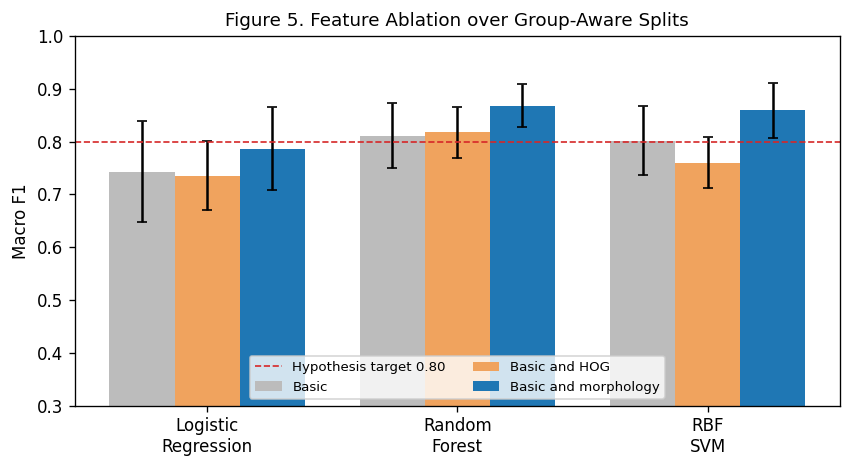

In [17]:
# Figure 5 compares the three feature families across the three models.
model_order, nice = ["logistic_regression", "random_forest", "svc_rbf"], ["Logistic\nRegression", "Random\nForest", "RBF\nSVM"]
fam_color = {"basic": "#bcbcbc", "basic+hog": "#f0a35e", "basic+morphology": "#1f77b4"}
fam_label = {"basic": "Basic", "basic+hog": "Basic and HOG", "basic+morphology": "Basic and morphology"}
piv = ablation.set_index(["family", "model"])
fig, ax = plt.subplots(figsize=(7.2, 4.0))
x, width = np.arange(len(model_order)), 0.26
for i, fam in enumerate(["basic", "basic+hog", "basic+morphology"]):
    means = [piv.loc[(fam, m), "macro_f1_mean"] for m in model_order]
    errs = [piv.loc[(fam, m), "macro_f1_std"] for m in model_order]
    ax.bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3, label=fam_label[fam], color=fam_color[fam])
ax.axhline(0.80, color="#d62728", ls="--", lw=1, label="Hypothesis target 0.80")
ax.set_xticks(x); ax.set_xticklabels(nice); ax.set_ylim(0.3, 1.0)
ax.set_ylabel("Macro F1")
ax.set_title("Figure 5. Feature Ablation over Group-Aware Splits", fontsize=11)
ax.legend(fontsize=8, ncol=2, loc="lower center")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig5_ablation.png"); plt.show()


## 8. Which features drive the decision
Read out the random forest permutation importances on data held out from training, checking the model relies on morphology rather than brightness artifacts.

Top 12 features by permutation importance (basic + morphology):

               feature  importance    std
          edge_density      0.0683 0.0161
mean_major_axis_length      0.0148 0.0142
     mean_eccentricity      0.0119 0.0106
 median_component_area      0.0091 0.0046
    max_component_area      0.0055 0.0048
       component_count      0.0050 0.0041
        mean_perimeter      0.0032 0.0059
         max_intensity      0.0024 0.0055
               entropy      0.0021 0.0036
          std_solidity      0.0020 0.0040
         p25_intensity      0.0018 0.0063
  total_component_area      0.0008 0.0025


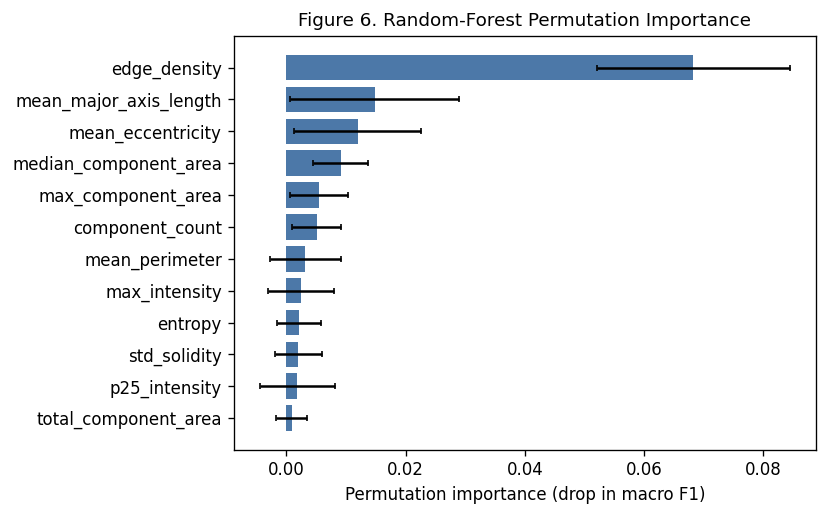

In [18]:
rf_imp = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)
rf_imp.fit(X_morph.iloc[train_idx], y.iloc[train_idx])
perm = permutation_importance(rf_imp, X_morph.iloc[test_idx], y.iloc[test_idx],
                              scoring="f1_macro", n_repeats=20, random_state=SEED, n_jobs=-1)
imp = (pd.DataFrame({"feature": X_morph.columns, "importance": perm.importances_mean, "std": perm.importances_std})
       .sort_values("importance", ascending=False).reset_index(drop=True))
print("Top 12 features by permutation importance (basic + morphology):\n")
print(imp.head(12).round(4).to_string(index=False))

top = imp.head(12).sort_values("importance")
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.barh(top["feature"], top["importance"], xerr=top["std"], color="#4c78a8", capsize=2)
ax.set_xlabel("Permutation importance (drop in macro F1)")
ax.set_title("Figure 6. Random-Forest Permutation Importance", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig6_importance.png"); plt.show()


## 9. Generalization across imaging conditions
Hold out each accelerating voltage in turn to test whether the features encode ordering or merely
the instrument.


In [19]:
# Train on all-but-one voltage and score the held-out voltage for each model.
def leave_one_voltage_out(X, model_protos):
    rows = []
    for v in sorted(kv.unique()):
        mask = (kv == v).to_numpy()
        if y[mask].nunique() < 2 or y[~mask].nunique() < 2:
            continue
        for name, proto in model_protos.items():
            s = score(y[mask], clone(proto).fit(X[~mask], y[~mask]).predict(X[mask]))
            rows.append({"held_out_kv": v.replace("p", "."), "model": name, "n_test": int(mask.sum()),
                         "macro_f1": round(s["macro_f1"], 3), "balanced_accuracy": round(s["balanced_accuracy"], 3)})
    return pd.DataFrame(rows)

lovo = leave_one_voltage_out(X_morph, MODEL_PROTOS)
print("Leave-one-voltage-out, engineered (basic + morphology) features:\n")
print(lovo.to_string(index=False))


Leave-one-voltage-out, engineered (basic + morphology) features:

held_out_kv               model  n_test  macro_f1  balanced_accuracy
     10.0kV logistic_regression     211     0.473              0.492
     10.0kV       random_forest     211     0.436              0.488
     10.0kV             svc_rbf     211     0.514              0.530
     20.0kV logistic_regression     174     0.484              0.491
     20.0kV       random_forest     174     0.538              0.535
     20.0kV             svc_rbf     174     0.567              0.555
     30.0kV logistic_regression     615     0.451              0.457
     30.0kV       random_forest     615     0.408              0.484
     30.0kV             svc_rbf     615     0.405              0.479


## 10. An upper bound from learned features (optional)
Benchmark frozen ImageNet ResNet-18 embeddings as the proposal's optional fourth family, treating their nearly perfect score within the training distribution as a confounded ceiling rather than a real result.

In [20]:
# Extract 512-dim frozen ResNet-18 embeddings, which is feature extraction only with no training.
def extract_cnn_embeddings(meta):
    cache = CACHE_DIR / "features_cnn.csv"
    if cache.exists():
        return pd.read_csv(cache)
    net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    net.fc = torch.nn.Identity(); net.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    net.to(device)
    prep = transforms.Compose([transforms.Grayscale(3), transforms.Resize((224, 224)), transforms.ToTensor(),
                               transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    rows, batch, batch_rows = [], [], []
    # Run one batch through the backbone and collect its embeddings.
    def flush():
        if not batch:
            return
        with torch.no_grad():
            emb = net(torch.stack(batch).to(device)).cpu().numpy()
        for r, v in zip(batch_rows, emb):
            rows.append({c: r[c] for c in TRACKING} | {f"cnn_{i:03d}": float(x) for i, x in enumerate(v)})
        batch.clear(); batch_rows.clear()
    print(f"Extracting ResNet-18 embeddings on {device} ...")
    for n, (_, r) in enumerate(meta.iterrows(), 1):
        with Image.open(r["path"]) as im:
            batch.append(prep(im))
        batch_rows.append(r)
        if len(batch) >= 32:
            flush()
        if n % 250 == 0:
            print(f"  cnn: {n}/{len(meta)}")
    flush()
    table = pd.DataFrame(rows); table.to_csv(cache, index=False)
    return table

cnn_ready = False
if RUN_CNN and TORCH_AVAILABLE:
    try:
        feat_cnn = extract_cnn_embeddings(metadata)
        X_cnn = feat_cnn[[c for c in feat_cnn.columns if c.startswith("cnn_")]]
        cnn_ready = True
        print("CNN embeddings:", X_cnn.shape)
    except Exception as exc:
        print("CNN section skipped:", repr(exc))
else:
    print("Skipping the learned-feature upper bound (RUN_CNN is False or PyTorch is unavailable).")


Extracting ResNet-18 embeddings on cpu ...


  cnn: 250/1000


  cnn: 500/1000


  cnn: 750/1000


  cnn: 1000/1000


CNN embeddings: (1000, 512)


In [21]:
if cnn_ready:
    # Tune an SVM on the embeddings with the same grouped protocol used everywhere else.
    cnn_svc, cnn_bench = tune(make_pipeline(StandardScaler(), SVC(class_weight="balanced", random_state=SEED)),
                              {"svc__C": [0.1, 1, 10], "svc__kernel": ["linear", "rbf"], "svc__gamma": ["scale"]}, X_cnn)
    cnn_model = make_pipeline(StandardScaler(), SVC(**{k.replace('svc__', ''): v for k, v in cnn_svc.best_params_.items()},
                                                    class_weight="balanced", random_state=SEED))
    # Report over 20 splits because the single benchmark split saturates at macro F1 1.0.
    cnn_f1 = np.array([f1_score(y.iloc[te], clone(cnn_model).fit(X_cnn.iloc[tr], y.iloc[tr]).predict(X_cnn.iloc[te]),
                                average="macro", zero_division=0) for tr, te in valid_group_splits(y, groups)])
    print("SVM on frozen CNN embeddings, best parameters:", cnn_svc.best_params_)
    print(f"  macro F1 over 20 splits: {cnn_f1.mean():.3f} ± {cnn_f1.std(ddof=1):.3f} "
          f"[{cnn_f1.min():.3f}, {cnn_f1.max():.3f}] | benchmark split {cnn_bench:.3f}")
    cnn_lovo = leave_one_voltage_out(X_cnn, {"svc_cnn": cnn_model})
    print("\nLeave-one-voltage-out, CNN embeddings:")
    print(cnn_lovo.to_string(index=False))


SVM on frozen CNN embeddings, best parameters: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
  macro F1 over 20 splits: 0.989 ± 0.010 [0.972, 1.000] | benchmark split 1.000



Leave-one-voltage-out, CNN embeddings:
held_out_kv   model  n_test  macro_f1  balanced_accuracy
     10.0kV svc_cnn     211     0.963              0.943
     20.0kV svc_cnn     174     0.911              0.878
     30.0kV svc_cnn     615     0.564              0.580


### 10.1 Is that nearly perfect score leakage?
Confirm that no specimen group is shared across the split, that no test crop has a nearly identical embedding in training, and that every specimen area carries a single label, so the score reflects a confound and not contamination.

In [22]:
if cnn_ready:
    # No specimen area appears on both sides of the split.
    overlap = len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))
    # No held-out crop is a near-duplicate of a training crop in embedding space.
    unit = lambda a: a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
    nn = (unit(X_cnn.iloc[test_idx].to_numpy()) @ unit(X_cnn.iloc[train_idx].to_numpy()).T).max(axis=1)
    # Every specimen area carries a single label, so specimen identity alone predicts the class.
    pure = (metadata.groupby("area_group")["label"].nunique() == 1).mean()
    print(f"area_group overlap train/test:            {overlap}")
    print(f"nearest-train cosine for test crops: max {nn.max():.3f}, twins > 0.999: {int((nn > 0.999).sum())}")
    print(f"fraction of specimen areas single-label:  {pure:.2f}")
    print("\nNo contamination: splits are group-disjoint and no near-duplicate crosses the split.")
    print("But labels are fixed by specimen area, so the embeddings recognize specimen and imaging")
    print("conditions rather than ordering; the voltage holdout above (0.56 at 30 kV) is the honest test.")


area_group overlap train/test:            0
nearest-train cosine for test crops: max 0.974, twins > 0.999: 0
fraction of specimen areas single-label:  1.00

No contamination: splits are group-disjoint and no near-duplicate crosses the split.
But labels are fixed by specimen area, so the embeddings recognize specimen and imaging
conditions rather than ordering; the voltage holdout above (0.56 at 30 kV) is the honest test.


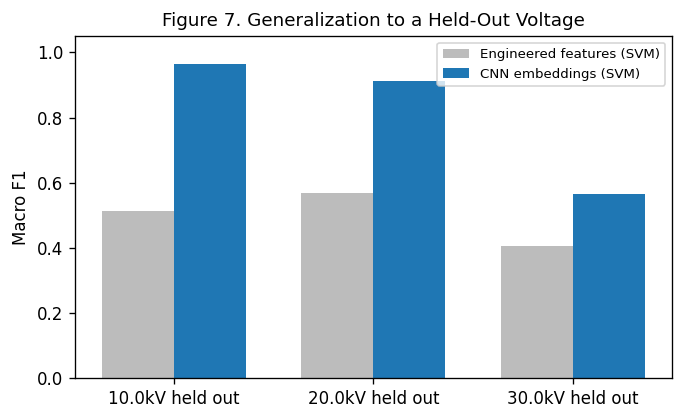

In [23]:
# Figure 7 contrasts held-out-voltage macro F1 for engineered features versus CNN embeddings.
if cnn_ready:
    eng, cnn = lovo[lovo["model"] == "svc_rbf"].set_index("held_out_kv"), cnn_lovo.set_index("held_out_kv")
    kvs, xx = list(eng.index), np.arange(len(eng.index))
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    ax.bar(xx - 0.18, [eng.loc[k, "macro_f1"] for k in kvs], 0.36, label="Engineered features (SVM)", color="#bcbcbc")
    ax.bar(xx + 0.18, [cnn.loc[k, "macro_f1"] for k in kvs], 0.36, label="CNN embeddings (SVM)", color="#1f77b4")
    ax.set_xticks(xx); ax.set_xticklabels([f"{k} held out" for k in kvs]); ax.set_ylim(0, 1.05)
    ax.set_ylabel("Macro F1"); ax.set_title("Figure 7. Generalization to a Held-Out Voltage", fontsize=11)
    ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FIG_DIR / "fig7_kv_holdout.png"); plt.show()


## 11. Error analysis
Break down the best model's test errors by magnification and class, and show a few misclassified crops.

In [24]:
best = make_models()["svc_rbf"].fit(X_morph.iloc[train_idx], y.iloc[train_idx])
test_meta = metadata.iloc[test_idx].copy()
test_meta["predicted"] = best.predict(X_morph.iloc[test_idx])
test_meta["correct"] = test_meta["predicted"] == test_meta["label"]
n_wrong = int((~test_meta["correct"]).sum())
print(f"Benchmark split: {n_wrong} of {len(test_meta)} misclassified ({n_wrong / len(test_meta):.1%})\n")
for by in ["mag", "label"]:
    tab = (test_meta.groupby(by).agg(n=("correct", "size"), errors=("correct", lambda s: int((~s).sum())))
           .assign(error_rate=lambda d: (d["errors"] / d["n"]).round(3)))
    print(f"Errors by {by}:\n{tab.to_string()}\n")


Benchmark split: 11 of 148 misclassified (7.4%)

Errors by mag:
       n  errors  error_rate
mag                         
100k  58       2       0.034
200k  32       5       0.156
50k   58       4       0.069

Errors by label:
              n  errors  error_rate
label                              
disordered   37       4       0.108
ordered     111       7       0.063



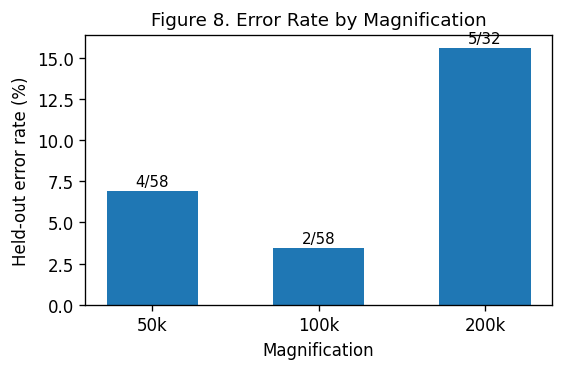

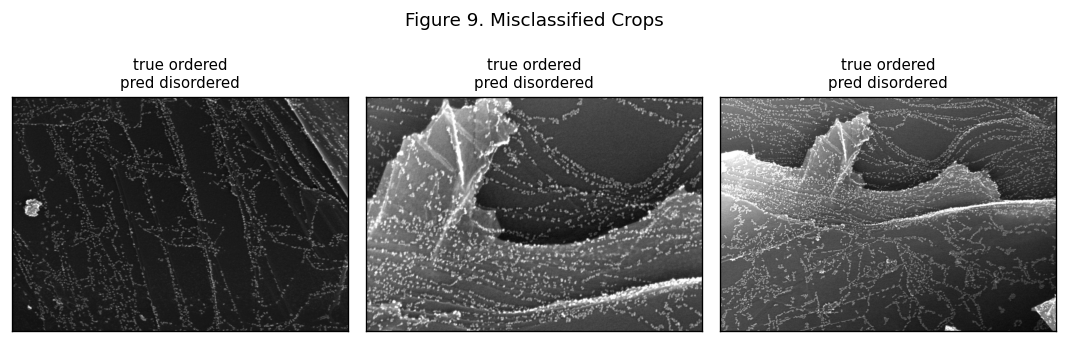

In [25]:
# Figure 8 shows the held-out error rate by magnification.
mag_tab = (test_meta.groupby("mag").agg(n=("correct", "size"), errors=("correct", lambda s: int((~s).sum())))
           .reindex(["50k", "100k", "200k"]))
mag_tab["rate"] = 100 * mag_tab["errors"] / mag_tab["n"]
fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.bar(mag_tab.index, mag_tab["rate"], color="#1f77b4", width=0.55)
for i, (e, n) in enumerate(zip(mag_tab["errors"], mag_tab["n"])):
    ax.text(i, mag_tab["rate"].iloc[i] + 0.3, f"{e}/{n}", ha="center", fontsize=9)
ax.set_xlabel("Magnification"); ax.set_ylabel("Held-out error rate (%)")
ax.set_title("Figure 8. Error Rate by Magnification", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig8_error_by_mag.png"); plt.show()

# Figure 9 shows a few misclassified crops, which tend to be borderline images.
wrong = test_meta[~test_meta["correct"]].head(3)
if len(wrong):
    fig, axes = plt.subplots(1, len(wrong), figsize=(3.0 * len(wrong), 3.2))
    for ax, (_, row) in zip(np.atleast_1d(axes), wrong.iterrows()):
        with Image.open(row["path"]) as im:
            ax.imshow(np.asarray(im.convert("L")), cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"true {row['label']}\npred {row['predicted']}", fontsize=9)
    fig.suptitle("Figure 9. Misclassified Crops", fontsize=11)
    fig.tight_layout(); fig.savefig(FIG_DIR / "fig9_misclassified.png"); plt.show()
